# Adaptive Topology Learning on PEMS-BAY

This notebook compares a **given-topology** GraphKoopman model
(`learn_topology=None`) to a **self-adaptive** model
(`learn_topology="self_adaptive"`) on PEMS-BAY traffic speeds when the teaching
cache is present. You will see how a WaveNet-style learned adjacency changes
multi-horizon forecast error relative to persistence, how dense row-softmax
$\hat{A}$ often stays near $1/N$ on short teaching fits, and why learned
adjacency is an inductive bias for forecasting — **not** causal road-network
discovery. Without the cache, the notebook uses a seeded synthetic ring
(`DATA_SOURCE=synthetic_fallback`) so it still executes end-to-end.

**Prerequisites.** Encode → Koopman step → decode from
[`01_synthetic_graph.ipynb`](01_synthetic_graph.ipynb); chronological traffic
protocol from [`03_traffic_network.ipynb`](03_traffic_network.ipynb).
Optional PEMS-BAY teaching cache (raw HDF5 not bundled):

```bash
python scripts/download_pems.py --benchmark bay --h5-path /path/to/pems-bay.h5
```



## Setup



In [1]:
import warnings

from tqdm.std import TqdmWarning

warnings.filterwarnings("ignore", category=TqdmWarning)

import csv
import hashlib
import io
import os
import random
from pathlib import Path
from urllib.error import URLError
from urllib.request import urlopen

import matplotlib

if os.environ.get("PYTEST_CURRENT_TEST") or os.environ.get("CI"):
    matplotlib.use("Agg")

import matplotlib.pyplot as plt
import numpy as np
import torch
from torch_geometric.data import Data

import koopman_graph
from koopman_graph import GNNDecoder, GNNEncoder, GraphKoopmanModel
from koopman_graph.analysis import estimate_coupling_from_snapshots
from koopman_graph.baselines.gnn.base import dense_adjacency
from koopman_graph.data import GraphSnapshotSequence, temporal_split
from koopman_graph.datasets.pems import (
    BAY_NUM_SENSORS,
    BAY_SENSOR_LOCATIONS_SHA256,
    BAY_SENSOR_LOCATIONS_URL,
    DEFAULT_BAY_CACHE_DIR,
    PemsBayTrafficBenchmark,
)
from koopman_graph.metrics import rmse as kg_rmse

IS_TEST = bool(
    os.environ.get("PYTEST_CURRENT_TEST")
    or os.environ.get("CI")
    or os.environ.get("IS_TEST")
)
SEED = 28
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

HIDDEN = 16 if IS_TEST else 48
LATENT = 8 if IS_TEST else 32
NUM_LAYERS = 2
EPOCHS = 2 if IS_TEST else 40
HORIZONS = (1, 2) if IS_TEST else (3, 6, 12)
TOP_K_EDGES = 12 if IS_TEST else 40
TOPOLOGY_EMBEDDING_DIM = 4 if IS_TEST else 8
LR = 1e-3
# Skip geography overlay when Â stays near-uniform (no entry ≫ 1/N).
NEAR_UNIFORM_MAX_RATIO = 1.5  # skip Top-K if max(Â) < 1.5 / N
UNIFORM_RANGE_FRAC = 0.25  # or if (max−min)/(1/N) is below this

print(f"koopman_graph {koopman_graph.__version__}")
print(
    f"IS_TEST={IS_TEST}  EPOCHS={EPOCHS}  HORIZONS={HORIZONS}  "
    f"TOP_K_EDGES={TOP_K_EDGES}"
)


koopman_graph 0.5.0
IS_TEST=False  EPOCHS=40  HORIZONS=(3, 6, 12)  TOP_K_EDGES=40


### Helpers



In [2]:
def load_bay_sensor_coords() -> tuple[np.ndarray, np.ndarray, list[str]]:
    # Download DCRNN PEMS-BAY locations CSV (sensor_id, lat, lon) with SHA256 check.
    try:
        with urlopen(BAY_SENSOR_LOCATIONS_URL, timeout=60) as response:
            raw = response.read()
    except URLError as exc:
        raise RuntimeError(
            "Failed to download PEMS-BAY sensor locations for geography plot.\n"
            f"URL: {BAY_SENSOR_LOCATIONS_URL}"
        ) from exc
    digest = hashlib.sha256(raw).hexdigest()
    if digest != BAY_SENSOR_LOCATIONS_SHA256:
        raise ValueError(
            f"SHA256 mismatch for sensor locations: got {digest}, "
            f"expected {BAY_SENSOR_LOCATIONS_SHA256}"
        )
    sensor_ids: list[str] = []
    lats: list[float] = []
    lons: list[float] = []
    reader = csv.reader(io.StringIO(raw.decode("utf-8")))
    for row in reader:
        if len(row) < 3:
            continue
        sensor_ids.append(row[0].strip())
        lats.append(float(row[1]))
        lons.append(float(row[2]))
    if len(sensor_ids) != BAY_NUM_SENSORS:
        raise ValueError(
            f"Expected {BAY_NUM_SENSORS} location rows, got {len(sensor_ids)}"
        )
    return np.asarray(lats), np.asarray(lons), sensor_ids


def make_synthetic_demo(
    *,
    num_nodes: int = 8,
    num_timesteps: int = 24,
    seed: int = SEED,
) -> tuple[GraphSnapshotSequence, np.ndarray, np.ndarray]:
    # Ring sequence with neighbor mixing so the given topology couples the series.
    generator = torch.Generator().manual_seed(seed)
    edge_src: list[int] = []
    edge_dst: list[int] = []
    for node in range(num_nodes):
        nxt = (node + 1) % num_nodes
        edge_src.extend([node, nxt])
        edge_dst.extend([nxt, node])
    edge_index = torch.tensor([edge_src, edge_dst], dtype=torch.long)
    features = torch.randn(num_timesteps, num_nodes, 1, generator=generator)
    for time in range(1, num_timesteps):
        prev = features[time - 1]
        neighbor_mean = torch.zeros_like(prev)
        for node in range(num_nodes):
            nxt = (node + 1) % num_nodes
            prv = (node - 1) % num_nodes
            neighbor_mean[node] = 0.5 * (prev[nxt] + prev[prv])
        noise = torch.randn(num_nodes, 1, generator=generator)
        features[time] = 0.7 * prev + 0.25 * neighbor_mean + 0.05 * noise
    sequence = GraphSnapshotSequence.from_arrays(features, edge_index)
    angles = np.linspace(0, 2 * np.pi, num_nodes, endpoint=False)
    lats = 37.3 + 0.05 * np.sin(angles)
    lons = -121.9 + 0.05 * np.cos(angles)
    return sequence, lats, lons


def persistence_predict(snapshot: Data, steps: int) -> list[Data]:
    kwargs = {"x": snapshot.x.clone(), "edge_index": snapshot.edge_index}
    edge_weight = getattr(snapshot, "edge_weight", None)
    if edge_weight is not None:
        kwargs["edge_weight"] = edge_weight
    return [Data(**kwargs) for _ in range(steps)]


def multi_origin_rmse(predict_fn, test_seq, horizons: tuple[int, ...]) -> dict[int, float]:
    max_horizon = max(horizons)
    origins = range(0, test_seq.num_timesteps - max_horizon)
    sums = {horizon: 0.0 for horizon in horizons}
    n_origins = 0
    for origin in origins:
        preds = predict_fn(test_seq[origin], max_horizon)
        for horizon in horizons:
            sums[horizon] += float(
                kg_rmse(preds[horizon - 1].x, test_seq[origin + horizon].x)
            )
        n_origins += 1
    if n_origins == 0:
        raise ValueError("no valid forecast origins for the requested horizons")
    return {horizon: sums[horizon] / n_origins for horizon in horizons}


def build_model(
    *,
    learn_topology: str | None,
    in_channels: int,
) -> GraphKoopmanModel:
    return GraphKoopmanModel(
        encoder=GNNEncoder(
            in_channels, HIDDEN, LATENT, num_layers=NUM_LAYERS
        ),
        decoder=GNNDecoder(
            LATENT, HIDDEN, in_channels, num_layers=NUM_LAYERS
        ),
        latent_dim=LATENT,
        time_step=300.0,
        dynamics_mode="discrete",
        koopman="graph",
        learn_topology=learn_topology,
        topology_embedding_dim=TOPOLOGY_EMBEDDING_DIM,
    )


def adjacency_flatness(adjacency: torch.Tensor) -> dict[str, float]:
    # Summarize how close a row-stochastic Â is to the uniform 1/N matrix.
    num_nodes = adjacency.shape[0]
    uniform = 1.0 / num_nodes
    values = adjacency.detach().cpu().reshape(-1)
    a_min = float(values.min())
    a_max = float(values.max())
    return {
        "n": float(num_nodes),
        "uniform": uniform,
        "mean": float(values.mean()),
        "min": a_min,
        "max": a_max,
        "range": a_max - a_min,
        "range_over_uniform": (a_max - a_min) / uniform,
    }


## Motivation and background

Standard KoopmanGraph training treats `edge_index` as **exogenous** — a
distance-kernel road graph for PEMS-BAY. Adaptive topology instead learns node
embeddings $E_1$, $E_2$ and forms

$$
\hat{A}_{\mathrm{adp}} = \mathrm{softmax}\bigl(\mathrm{ReLU}(E_1 E_2^{\top})\bigr)
$$

(Graph WaveNet construction; `Wu2019WaveNet`), then **replaces** the supplied
pairwise edges for encode / graph advance / spectrum. Because every row is a
softmax over all $N$ nodes, an unregularized fit can stay near the uniform
matrix $1/N$ when embeddings do not sparsify — that is a property of the
construction, not a plotting bug.

Related work connects GNN propagation to DMD-style linear operators (DMD-GNN,
ICLR 2025, arXiv:2410.05593). This notebook's DMD helper
(`estimate_coupling_from_snapshots`) is a **diagnostic** companion — useful for
visual comparison or warm-start ideas, not a claim that either matrix recovers
true causal links.

**Honest scope.** Learned adjacency is not unique and is optimized for forecast
loss. Prefer the given DCRNN distance graph when geography is trusted and the
adaptive model does not improve holdout error relative to that baseline (and
always check persistence before claiming skill).



## Minimal example: self-adaptive adjacency shape

Fit a tiny adaptive model on a seeded ring (neighbor-coupled synthetic series)
and confirm `dense_adjacency()` is $(N, N)$ and row-stochastic. This API check
runs before loading PEMS-BAY.



In [3]:
demo_seq, _demo_lats, _demo_lons = make_synthetic_demo(
    num_nodes=8, num_timesteps=16, seed=SEED
)
torch.manual_seed(SEED)
mini = build_model(
    learn_topology="self_adaptive",
    in_channels=demo_seq.in_channels,
)
_ = mini.fit(demo_seq[:8], epochs=1, lr=LR)
_ = mini.encode(demo_seq[0])
A_mini = mini.adaptive_topology.dense_adjacency().detach()
flat = adjacency_flatness(A_mini)
print("learned Â shape:", tuple(A_mini.shape))
print(
    "row sums (min/max):",
    float(A_mini.sum(dim=1).min()),
    float(A_mini.sum(dim=1).max()),
)
print(
    f"Â vs 1/N: mean={flat['mean']:.6f}  uniform={flat['uniform']:.6f}  "
    f"range={flat['range']:.6e}"
)
print("DATA_SOURCE for minimal example: synthetic_demo")



learned Â shape: (8, 8)
row sums (min/max): 0.9999998807907104 1.0000001192092896
Â vs 1/N: mean=0.125000  uniform=0.125000  range=9.543478e-03
DATA_SOURCE for minimal example: synthetic_demo


## Load PEMS-BAY (or synthetic fallback)

Interactive runs prefer `data/pems_bay/traffic.pt` and fetch sensor lat/lon from
the DCRNN locations CSV (SHA256-verified). If that teaching cache is missing,
the notebook falls back to a seeded synthetic ring demo
(`DATA_SOURCE=synthetic_fallback`) so Restart & Run All still works. Under
pytest / CI we always use the synthetic path (`synthetic_ci`). Geography plots
are illustrative — they are not a road-network validation of $\hat{A}$.



In [4]:
FEATURE_UNIT = "synthetic node feature (dimensionless)"
DATA_SOURCE = "synthetic"

if IS_TEST:
    sequence, lats, lons = make_synthetic_demo()
    DATA_SOURCE = "synthetic_ci"
else:
    cache_path = DEFAULT_BAY_CACHE_DIR / "traffic.pt"
    if not cache_path.exists():
        print(
            "PEMS-BAY teaching cache is missing; using a seeded synthetic ring "
            "demo. Build the cache with (HDF5 not bundled):\n"
            "  python scripts/download_pems.py --benchmark bay "
            "--h5-path /path/to/pems-bay.h5\n"
            "See docs/source/data.rst for the PEMS-BAY dataset card."
        )
        # Long enough that 70/10/20 temporal_split leaves test T > max(HORIZONS).
        sequence, lats, lons = make_synthetic_demo(
            num_nodes=8,
            num_timesteps=80,
            seed=SEED,
        )
        DATA_SOURCE = "synthetic_fallback"
    else:
        sequence = PemsBayTrafficBenchmark.load_sequence()
        topology = PemsBayTrafficBenchmark.load_topology()
        lats, lons, location_ids = load_bay_sensor_coords()
        if topology.sensor_ids is not None:
            id_to_row = {sid: i for i, sid in enumerate(location_ids)}
            order = [id_to_row[sid] for sid in topology.sensor_ids]
            lats = lats[order]
            lons = lons[order]
        DATA_SOURCE = "pems_bay"
        FEATURE_UNIT = "z-scored speed (dimensionless)"
        print(
            f"nodes={sequence.num_nodes}  T={sequence.num_timesteps}  "
            f"edges={sequence.edge_index.shape[1]}"
        )

in_channels = sequence.in_channels
print(f"DATA_SOURCE={DATA_SOURCE}  feature unit: {FEATURE_UNIT}")
print(f"T={sequence.num_timesteps} N={sequence.num_nodes} F={in_channels}")



nodes=325  T=288  edges=4483
DATA_SOURCE=pems_bay  feature unit: z-scored speed (dimensionless)
T=288 N=325 F=1


## Matched given vs adaptive comparison

Chronological `temporal_split` (70/10/20), shared horizons / capacity / seed.
Only `learn_topology` differs. Persistence repeats the last observation and is
the skill floor before claiming either Koopman model helps.



In [5]:
split = temporal_split(sequence)
print(
    f"train/val/test T = "
    f"{split.train.num_timesteps}/"
    f"{split.val.num_timesteps}/"
    f"{split.test.num_timesteps}"
)

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
given_model = build_model(learn_topology=None, in_channels=in_channels)
given_history = given_model.fit(
    split.train,
    epochs=EPOCHS,
    lr=LR,
    validation_sequence=split.val,
    early_stopping_patience=max(3, EPOCHS // 3),
    restore_best_weights=True,
)

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
adapt_model = build_model(
    learn_topology="self_adaptive",
    in_channels=in_channels,
)
adapt_history = adapt_model.fit(
    split.train,
    epochs=EPOCHS,
    lr=LR,
    validation_sequence=split.val,
    early_stopping_patience=max(3, EPOCHS // 3),
    restore_best_weights=True,
)
_ = adapt_model.encode(split.train[0])

print(
    f"final train loss  given={given_history.loss[-1]:.4f}  "
    f"adaptive={adapt_history.loss[-1]:.4f}"
)



train/val/test T = 201/28/59


final train loss  given=0.4071  adaptive=0.4582


## DMD coupling diagnostic (train window)

Absolute threshold is the 90th percentile of off-diagonal coupling magnitudes
so the sparse support stays readable. Treat this as a **linear diagnostic**,
not a topology ground truth.



In [6]:
coupling_probe = estimate_coupling_from_snapshots(
    split.train, threshold=0.0, rank=min(8, split.train.num_nodes)
)
off_diag = coupling_probe.coupling.clone()
off_diag.fill_diagonal_(0.0)
threshold = float(torch.quantile(off_diag.flatten(), 0.90))
dmd_estimate = estimate_coupling_from_snapshots(
    split.train, threshold=threshold, rank=min(8, split.train.num_nodes)
)
print(
    f"DMD threshold (p90)={threshold:.4f}  "
    f"sparse edges={dmd_estimate.edge_index.shape[1]}"
)



DMD threshold (p90)=0.0114  sparse edges=10563


## Results: multi-horizon MAE / RMSE

Metrics use the active `FEATURE_UNIT` (z-scored speed on PEMS-BAY; synthetic
units on the fallback / CI paths). **Look at three things in the bar chart:**
(1) which model has the lowest aggregate RMSE on *this* run, (2) whether
adaptive improves on the given exogenous graph, and (3) whether either Koopman
model beats persistence. Always read the printed `DATA_SOURCE` before
generalizing.



DATA_SOURCE=pems_bay
Units: MAE/RMSE in z-scored speed (dimensionless)
given         agg_rmse=2.5777  h3_rmse=0.7508  h6_rmse=1.5464  h12_rmse=5.4359
adaptive      agg_rmse=2.2474  h3_rmse=0.7420  h6_rmse=1.3680  h12_rmse=4.6322
persistence   agg_rmse=0.5953  h3_rmse=0.5071  h6_rmse=0.5797  h12_rmse=0.6989


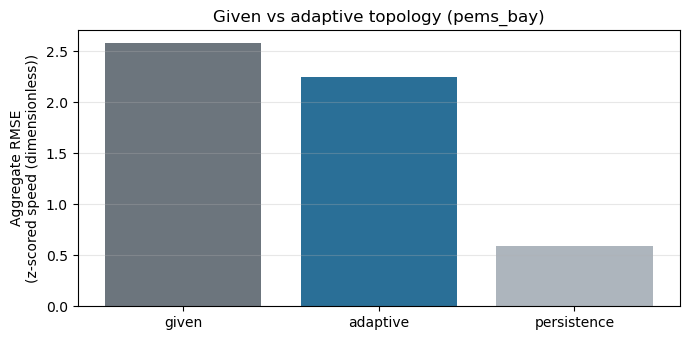

Lowest aggregate RMSE on this run: persistence
Adaptive vs given: adaptive lower (Δ=+0.3303)
Vs persistence: neither Koopman model beats persistence on aggregate RMSE
DATA_SOURCE=pems_bay


In [7]:
given_eval = given_model.evaluate(split.test, horizons=HORIZONS)
adapt_eval = adapt_model.evaluate(split.test, horizons=HORIZONS)
persist_rmses = multi_origin_rmse(persistence_predict, split.test, HORIZONS)

rows = []
for name, result in (("given", given_eval), ("adaptive", adapt_eval)):
    row = {
        "model": name,
        "aggregate_mae": result.aggregate_mae,
        "aggregate_rmse": result.aggregate_rmse,
    }
    for metric in result.horizons:
        row[f"h{metric.horizon}_rmse"] = metric.rmse
        row[f"h{metric.horizon}_mae"] = metric.mae
    rows.append(row)
rows.append(
    {
        "model": "persistence",
        "aggregate_mae": float("nan"),
        "aggregate_rmse": float(np.mean(list(persist_rmses.values()))),
        **{f"h{h}_rmse": persist_rmses[h] for h in HORIZONS},
        **{f"h{h}_mae": float("nan") for h in HORIZONS},
    }
)

print(f"DATA_SOURCE={DATA_SOURCE}")
print(f"Units: MAE/RMSE in {FEATURE_UNIT}")
for row in rows:
    parts = [
        f"{row['model']:12s}",
        f"agg_rmse={row['aggregate_rmse']:.4f}",
    ]
    for horizon in HORIZONS:
        parts.append(f"h{horizon}_rmse={row[f'h{horizon}_rmse']:.4f}")
    print("  ".join(parts))

labels = [row["model"] for row in rows]
agg = [row["aggregate_rmse"] for row in rows]
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.bar(labels, agg, color=["#6c757d", "#2a6f97", "#adb5bd"])
ax.set_ylabel(f"Aggregate RMSE\n({FEATURE_UNIT})")
ax.set_title(f"Given vs adaptive topology ({DATA_SOURCE})")
ax.grid(axis="y", alpha=0.3)
fig.tight_layout()
plt.show()

by_name = {row["model"]: row["aggregate_rmse"] for row in rows}
winner = min(rows, key=lambda row: row["aggregate_rmse"])["model"]
print(f"Lowest aggregate RMSE on this run: {winner}")
print(
    "Adaptive vs given: "
    f"{'adaptive lower' if by_name['adaptive'] < by_name['given'] else 'given lower or tied'} "
    f"(Δ={by_name['given'] - by_name['adaptive']:+.4f})"
)
print(
    "Vs persistence: "
    + (
        "neither Koopman model beats persistence on aggregate RMSE"
        if by_name["persistence"] <= min(by_name["given"], by_name["adaptive"])
        else "at least one Koopman model beats persistence"
    )
)
if DATA_SOURCE.startswith("synthetic"):
    print(
        f"DATA_SOURCE={DATA_SOURCE} — do not treat synthetic runs as "
        "PEMS-BAY results."
    )
else:
    print(f"DATA_SOURCE={DATA_SOURCE}")



## Visualization: adjacency heatmaps and residual

Panels: (i) exogenous given adjacency on a fixed $[0, 1]$ scale, (ii) learned
row-stochastic $\hat{A}$ on a fixed scale anchored at $1/N$ (so a flat
softmax does **not** auto-scale into fake structure). When $\hat{A}$ is not
near-uniform, a third panel shows residual $\hat{A} - 1/N$ with a **fixed**
color scale $\pm 1/N$ (not auto-scaled speckles). When $\hat{A}$ is
near-uniform, the residual panel is omitted. A separate DMD magnitude plot is a
linear diagnostic only.

If $\max(\hat{A}) < 1.5/N$ (or the entry range is a small fraction of
$1/N$), the Top-$K$ geography overlay is **skipped** — ranking
near-uniform weights is not structure discovery. On synthetic runs the
coordinates are fake ring positions.



Learned Â: mean=0.003077  1/N=0.003077  min=0.003017  max=0.003545  range/uniform=0.1715
Â is near-uniform (dense row-softmax did not sparsify on this fit). Do not read heatmap speckles or Top-K edges as recovered roads.
Omitting residual panel: Â ≈ 1/N (auto-scaled residuals would be noise).


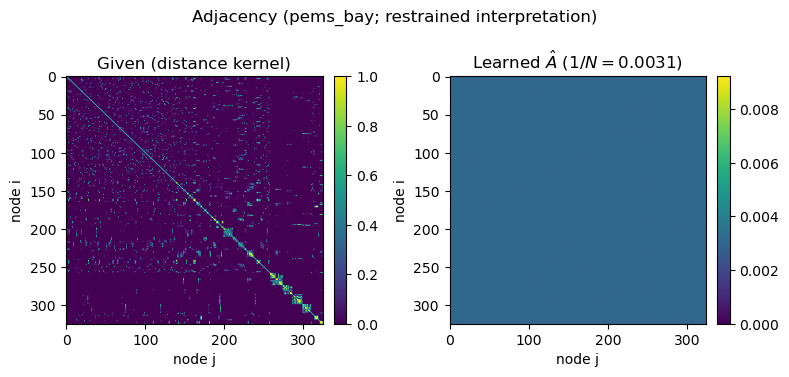

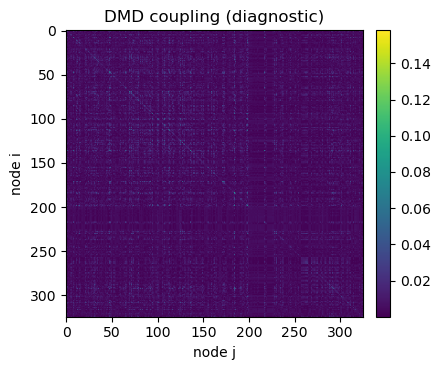

Skipping Top-40 geography overlay: max/(1/N)=1.152, range/uniform=0.1715.


In [8]:
A_given = dense_adjacency(
    sequence.edge_index,
    sequence.edge_weight,
    sequence.num_nodes,
).detach().cpu()
A_learned = adapt_model.adaptive_topology.dense_adjacency().detach().cpu()
A_dmd = dmd_estimate.coupling.detach().cpu()
flat = adjacency_flatness(A_learned)
uniform = flat["uniform"]
print(
    f"Learned Â: mean={flat['mean']:.6f}  1/N={uniform:.6f}  "
    f"min={flat['min']:.6f}  max={flat['max']:.6f}  "
    f"range/uniform={flat['range_over_uniform']:.4f}"
)
nearly_uniform = (
    flat["max"] / uniform < NEAR_UNIFORM_MAX_RATIO
    or flat["range_over_uniform"] < UNIFORM_RANGE_FRAC
)
if nearly_uniform:
    print(
        "Â is near-uniform (dense row-softmax did not sparsify on this fit). "
        "Do not read heatmap speckles or Top-K edges as recovered roads."
    )

given_title = (
    "Given (distance kernel)"
    if DATA_SOURCE == "pems_bay"
    else "Given (ring / synthetic)"
)
learned_vmax = max(3.0 * uniform, flat["max"])
residual = A_learned - uniform

n_panels = 2 if nearly_uniform else 3
fig, axes = plt.subplots(1, n_panels, figsize=(4.0 * n_panels, 3.8))
if n_panels == 2:
    axes = list(axes)

im0 = axes[0].imshow(
    A_given.numpy(), aspect="auto", cmap="viridis", vmin=0.0, vmax=1.0
)
axes[0].set_title(given_title)
fig.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

im1 = axes[1].imshow(
    A_learned.numpy(),
    aspect="auto",
    cmap="viridis",
    vmin=0.0,
    vmax=learned_vmax,
)
axes[1].set_title(rf"Learned $\hat{{A}}$ ($1/N={uniform:.4f}$)")
fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

if nearly_uniform:
    print("Omitting residual panel: Â ≈ 1/N (auto-scaled residuals would be noise).")
else:
    # Fixed ±1/N so small fluctuations cannot dominate the color scale.
    im2 = axes[2].imshow(
        residual.numpy(),
        aspect="auto",
        cmap="RdBu_r",
        vmin=-uniform,
        vmax=uniform,
    )
    axes[2].set_title(r"Residual $\hat{A}-1/N$ (fixed $\pm 1/N$)")
    fig.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04)

for ax in axes:
    ax.set_xlabel("node j")
    ax.set_ylabel("node i")
fig.suptitle(f"Adjacency ({DATA_SOURCE}; restrained interpretation)")
fig.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(4.5, 3.8))
im = ax.imshow(A_dmd.numpy(), aspect="auto", cmap="viridis")
ax.set_title("DMD coupling (diagnostic)")
ax.set_xlabel("node j")
ax.set_ylabel("node i")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
fig.tight_layout()
plt.show()

learned_index, learned_weight = adapt_model.adaptive_topology.materialize()
learned_index = learned_index.detach().cpu()
learned_weight = learned_weight.detach().cpu()
mask = learned_index[0] != learned_index[1]
learned_index = learned_index[:, mask]
learned_weight = learned_weight[mask]

if nearly_uniform:
    print(
        f"Skipping Top-{TOP_K_EDGES} geography overlay: "
        f"max/(1/N)={flat['max'] / uniform:.3f}, "
        f"range/uniform={flat['range_over_uniform']:.4f}."
    )
else:
    topk = min(TOP_K_EDGES, int(learned_weight.numel()))
    order = torch.topk(learned_weight, k=topk).indices
    print(
        f"Top-{topk} weight min/max among selected: "
        f"{float(learned_weight[order].min()):.6f} / "
        f"{float(learned_weight[order].max()):.6f}"
    )
    fig, ax = plt.subplots(figsize=(6.5, 5.5))
    ax.scatter(lons, lats, s=18, c="#6c757d", alpha=0.85, zorder=2)
    for idx in order.tolist():
        i = int(learned_index[0, idx])
        j = int(learned_index[1, idx])
        ax.plot(
            [lons[i], lons[j]],
            [lats[i], lats[j]],
            color="#2a6f97",
            alpha=0.35,
            linewidth=1.0,
            zorder=1,
        )
    ax.set_xlabel("longitude")
    ax.set_ylabel("latitude")
    ax.set_title(
        f"Top-{topk} learned edges ({DATA_SOURCE}; not road truth)"
    )
    ax.grid(True, alpha=0.25)
    fig.tight_layout()
    plt.show()


## Interpretation

Connect the Results bar chart and adjacency panels back to the motivation:

- **This run's ranking.** Read the printed winner and the adaptive-vs-given /
  vs-persistence lines. On short PEMS teaching windows it is common for
  **persistence to beat both** Koopman models even when adaptive improves on
  the given distance graph.
- **Near-uniform** $\hat{A}$. Dense
  $\mathrm{softmax}\bigl(\mathrm{ReLU}(E_1 E_2^{\top})\bigr)$ can remain within
  a few percent of $1/N$. Flatness shows up in the fixed-scale $\hat{A}$ panel
  and the printed $1/N$ stats; when $\hat{A}$ is near-uniform the residual
  panel is omitted so auto-scaled speckles cannot look like structure. When a
  residual is shown, it uses a fixed $\pm 1/N$ scale.
- **Identifiability.** Many $\hat{A}$ matrices can yield similar forecasts;
  do not treat learned edges as causal discovery or as replacements for
  surveyed road networks.
- **Cost.** Self-adaptive mode materializes dense $N^{2}$ COO — acceptable for
  PEMS-BAY teaching size, expensive for the largest PEMS graphs.
- **DMD panel.** Linear snapshot-to-snapshot diagnostic only; thresholded edges
  are for visualization, not a graph prior unless you explicitly warm-start.



## Takeaways

- Use `learn_topology="self_adaptive"` when you want Graph WaveNet-style dense
  adjacency threaded through encode and `koopman="graph"` advance — not when
  you need sparse causal topology recovery.
- Keep `learn_topology=None` when the exogenous graph is trusted **or** when
  adaptive does not improve holdout error versus that given graph.
- Always include persistence under chronological holdout with named units
  before claiming Koopman skill; on this notebook's teaching settings
  persistence is often best.
- If $\hat{A} \approx 1/N$, treat heatmaps / Top-$K$ maps as non-informative
  for structure; the API still ran, but the inductive bias did not sparsify.
- Read `DATA_SOURCE`: PEMS-BAY metrics require the teaching cache;
  `synthetic_fallback` / `synthetic_ci` only demonstrate the API path.



## Further reading

- API: `GraphKoopmanModel(..., learn_topology="self_adaptive")`,
  `AdaptiveAdjacency.dense_adjacency`, `materialize_learned_topology`,
  `koopman_graph.analysis.estimate_coupling_from_snapshots`
- Dataset card: Sphinx `docs/source/data.rst` — PEMS-BAY
- Related notebooks: [`03_traffic_network.ipynb`](03_traffic_network.ipynb),
  [`18_networked_koopman_dynamic_topology.ipynb`](18_networked_koopman_dynamic_topology.ipynb),
  [`22_gnn_forecaster_comparison.ipynb`](22_gnn_forecaster_comparison.ipynb),
  [`27_hypergraph_koopman.ipynb`](27_hypergraph_koopman.ipynb)
- Citations (`paper.bib`): `Wu2019WaveNet`, `Li2018DCRNN`, `Shi2025DMDGNN`

